In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from controllers.pid import PidController
from sim.plant import act, k
from sim.runner import run_tracking, tracking_metrics, settling_times
from sim.trajectories import circle_ref, figure8_ref, waypoint_ref

In [20]:
dt = 0.02
f_limit = 4 * act["wheel_force_max_n"]
m_limit = f_limit * k

#stiffness = mass x frequency(for the kp,kd and ki values)(expdrimental values of kp,ki and kd)
gains = {"kp": (60.0, 60.0, 7.0), "ki": (0.0, 0.0, 0.0), "kd": (130.0, 130.0, 28.0)}
pid = PidController(gains, dt, f_limit, m_limit)

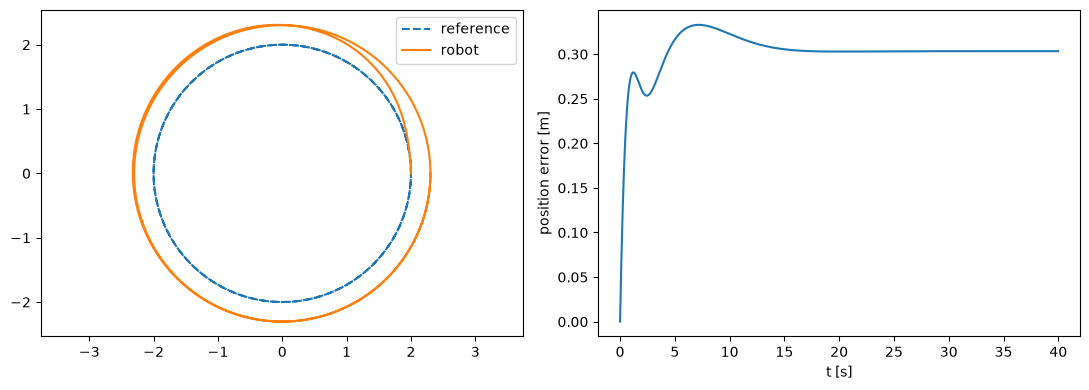

In [21]:
pid.reset()

res = run_tracking(pid, circle_ref, 40.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(res["ref"][:, 0], res["ref"][:, 1], "--", label="reference")
axes[0].plot(res["states"][:, 0], res["states"][:, 1], label="robot")
axes[0].axis("equal")
axes[0].legend()
err = np.linalg.norm(res["states"][:, :2] - res["ref"][:, :2], axis=1)
axes[1].plot(res["t"], err)
axes[1].set(xlabel="t [s]", ylabel="position error [m]")
plt.tight_layout()

In [22]:
runs = [("circle", circle_ref, 40.0), ("figure8", figure8_ref, 60.0), ("waypoints", waypoint_ref, 25.0)]
rows =[]
for name, ref_fn, duration in runs:
    pid.reset()
    res = run_tracking(pid, ref_fn, duration)
    rows.append({"controller": "pid", "trajectory": name, **tracking_metrics(res)})

df = pd.DataFrame(rows)
df.to_csv("../results/pid_nominal.csv", index=False)
df

,controller,trajectory,pos_rmse,heading_rmse,effort,compute_ms_mean,compute_ms_max
0,pid,circle,0.303232,3.181519e-02,16365.570938,0.009358,0.073084
1,pid,figure8,0.188189,9.915326e-02,13063.683197,0.008781,0.052250
2,pid,waypoints,0.834460,1.390930e-16,11347.554231,0.008794,0.041708


In [23]:
pid.reset()
res = run_tracking(pid, waypoint_ref, 25.0)
settling_times(res)

[0.0, nan, nan, np.float64(5.82)]